Practical no:04

Priyanka Jadhav

RollNo:13210(B1)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x=np.array([95,85,80,70,60])
y=np.array([85,95,70,65,70])

In [3]:
model= np.polyfit(x, y, 1)
model

array([ 0.64383562, 26.78082192])

In [4]:
predict = np.poly1d(model)
print("Prediction for 65:", predict(65))

Prediction for 65: 68.63013698630135


In [5]:
y_pred = predict(x)
print("Predicted values:", y_pred)

Predicted values: [87.94520548 81.50684932 78.28767123 71.84931507 65.4109589 ]


In [6]:
from sklearn.metrics import r2_score
print("R2 Score:", r2_score(y, y_pred))

R2 Score: 0.4803218090889323


In [7]:
y_line = model[1] + model[0] * x

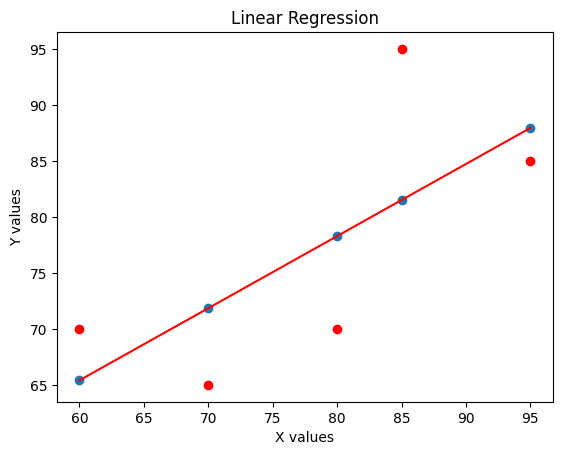

In [8]:
plt.plot(x, y_line, c='r')
plt.scatter(x, y_pred)
plt.scatter(x, y, c='r')
plt.xlabel("X values")
plt.ylabel("Y values")
plt.title("Linear Regression")
plt.show()

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
df = pd.read_csv("Boston-house-price-data.csv")

In [12]:
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB
None


In [14]:
data = X.copy()
data.columns = data.columns.str.strip()
target_column = data.columns[-1]
x = data.drop(target_column, axis=1)
y = data[target_column]

In [15]:
print("Target column is:", target_column)
print(x.shape, y.shape)

Target column is: LSTAT
(506, 12) (506,)


In [16]:
from sklearn.model_selection import train_test_split

In [17]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    test_size=0.2,
    random_state=0
)

In [18]:
print(xtrain.shape, xtest.shape)
print(ytrain.shape, ytest.shape)

(404, 12) (102, 12)
(404,) (102,)


In [19]:
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(xtrain, ytrain)

print("Model training completed ✅")

Model training completed ✅


In [20]:
ytrain_pred = lm.predict(xtrain)
ytest_pred = lm.predict(xtest)

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Train R2:", r2_score(ytrain, ytrain_pred))
print("Test R2:", r2_score(ytest, ytest_pred))
print("Train MSE:", mean_squared_error(ytrain, ytrain_pred))
print("Test MSE:", mean_squared_error(ytest, ytest_pred))

Train R2: 0.6830386021775365
Test R2: 0.4970790902412058
Train MSE: 16.84458940970367
Test MSE: 21.085848548855335


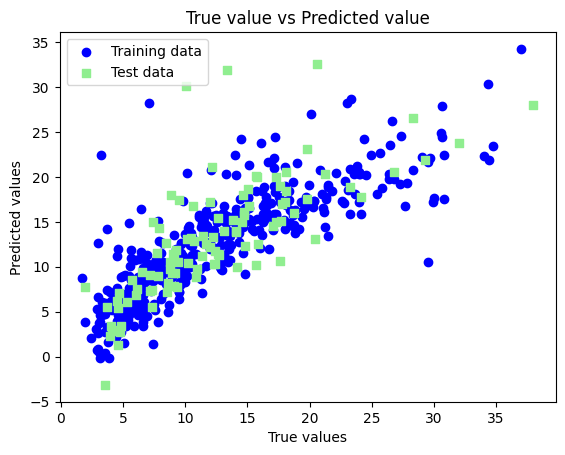

In [22]:
plt.scatter(ytrain, ytrain_pred, c='blue', marker='o', label='Training data')
plt.scatter(ytest, ytest_pred, c='lightgreen', marker='s', label='Test data')

plt.xlabel('True values')
plt.ylabel('Predicted values')
plt.title("True value vs Predicted value")

plt.legend(loc='upper left')
plt.show()